 # 05 - Ablation Study

 **Goal:** Analyze the impact of embedding dimension on model performance.

In [1]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader
import sys
import os
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('../src'))
from models.mf import MatrixFactorization
from models.ncf import NeuMF
from data_loader import ImplicitFeedbackDataset
from metrics import precision_at_k, recall_at_k, ndcg_at_k

FIGURES_DIR = 'reports/figures'
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300


In [2]:
# Load data
train_df = pd.read_parquet('../data/processed/train.parquet')
val_df = pd.read_parquet('../data/processed/val.parquet')
test_df = pd.read_parquet('../data/processed/test.parquet')

all_df = pd.concat([train_df, val_df, test_df])
unique_users = all_df['reviewerID'].unique()
unique_items = all_df['asin'].unique()

user_map = {u: i for i, u in enumerate(unique_users)}
item_map = {i: idx for idx, i in enumerate(unique_items)}
reverse_item_map = {idx: i for idx, i in enumerate(unique_items)}

n_users = len(user_map)
n_items = len(item_map)

train_df['reviewerID_idx'] = train_df['reviewerID'].map(user_map)
train_df['asin_idx'] = train_df['asin'].map(item_map)

print(f"Users: {n_users}, Items: {n_items}")


Users: 368, Items: 282


 ## Ablation: Embedding Dimension

In [3]:
def evaluate_quick(model, test_df, train_df, device, k=10):
    """Quick evaluation on a subset of users."""
    users = test_df['reviewerID'].unique()[:100]  # Subset for speed
    
    ground_truth = test_df.groupby('reviewerID')['asin'].apply(set).to_dict()
    seen_items = train_df.groupby('reviewerID')['asin'].apply(set).to_dict()
    
    ndcg_scores = []
    
    for user in users:
        if user not in ground_truth or user not in user_map:
            continue
        
        true_items = ground_truth[user]
        seen = seen_items.get(user, set())
        
        u_idx = user_map[user]
        mapped_exclude = [item_map[i] for i in seen if i in item_map]
        rec_indices = model.recommend(u_idx, k=k, exclude=mapped_exclude, device=device)
        recs = [reverse_item_map[i] for i in rec_indices]
        
        ndcg_scores.append(ndcg_at_k(recs, true_items, k))
    
    return np.mean(ndcg_scores) if ndcg_scores else 0.0

def train_model(ModelClass, n_users, n_items, embedding_dim, epochs=20):
    """Train a model with given embedding dimension."""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    if ModelClass == MatrixFactorization:
        model = ModelClass(n_users, n_items, n_factors=embedding_dim).to(device)
        lr = 0.005
    else:
        model = ModelClass(n_users, n_items, factor_num=embedding_dim).to(device)
        lr = 0.001
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = torch.nn.BCEWithLogitsLoss()
    
    dataset = ImplicitFeedbackDataset(train_df, n_users, n_items, num_negatives=4)
    loader = DataLoader(dataset, batch_size=256, shuffle=True)
    
    for epoch in range(epochs):
        model.train()
        for u, i, negs in loader:
            u, i, negs = u.to(device), i.to(device), negs.to(device)
            
            pos_pred = model(u, i)
            loss = loss_fn(pos_pred, torch.ones_like(pos_pred))
            
            for n_idx in range(negs.shape[1]):
                neg_pred = model(u, negs[:, n_idx])
                loss += loss_fn(neg_pred, torch.zeros_like(neg_pred))
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
    model.eval()
    return model, device


In [4]:
# Test embedding dimensions
embedding_dims = [16, 32, 64, 128]
results = {'Model': [], 'Embedding Dim': [], 'NDCG@10': []}

print("Running ablation study...")
print("=" * 50)

for dim in embedding_dims:
    print(f"\nTesting embedding_dim = {dim}")
    
    # MF
    mf_model, device = train_model(MatrixFactorization, n_users, n_items, dim, epochs=20)
    mf_ndcg = evaluate_quick(mf_model, test_df, train_df, device)
    results['Model'].append('MF')
    results['Embedding Dim'].append(dim)
    results['NDCG@10'].append(mf_ndcg)
    print(f"  MF NDCG@10: {mf_ndcg:.4f}")
    
    # NCF
    ncf_model, device = train_model(NeuMF, n_users, n_items, dim, epochs=20)
    ncf_ndcg = evaluate_quick(ncf_model, test_df, train_df, device)
    results['Model'].append('NCF')
    results['Embedding Dim'].append(dim)
    results['NDCG@10'].append(ncf_ndcg)
    print(f"  NCF NDCG@10: {ncf_ndcg:.4f}")


Running ablation study...

Testing embedding_dim = 16
  MF NDCG@10: 0.0072
  NCF NDCG@10: 0.0087

Testing embedding_dim = 32
  MF NDCG@10: 0.0116
  NCF NDCG@10: 0.0090

Testing embedding_dim = 64
  MF NDCG@10: 0.0095
  NCF NDCG@10: 0.0118

Testing embedding_dim = 128
  MF NDCG@10: 0.0011
  NCF NDCG@10: 0.0097


In [5]:
results_df = pd.DataFrame(results)
print("\n" + "=" * 50)
print("ABLATION STUDY RESULTS")
print("=" * 50)
print(results_df.to_string(index=False))

# Save results
results_df.to_csv(f'{FIGURES_DIR}/ablation_results.csv', index=False)
print(f"\nSaved: {FIGURES_DIR}/ablation_results.csv")



ABLATION STUDY RESULTS
Model  Embedding Dim  NDCG@10
   MF             16 0.007184
  NCF             16 0.008724
   MF             32 0.011605
  NCF             32 0.008974
   MF             64 0.009499
  NCF             64 0.011790
   MF            128 0.001070
  NCF            128 0.009702

Saved: reports/figures/ablation_results.csv


Saved: reports/figures/fig_ablation.png


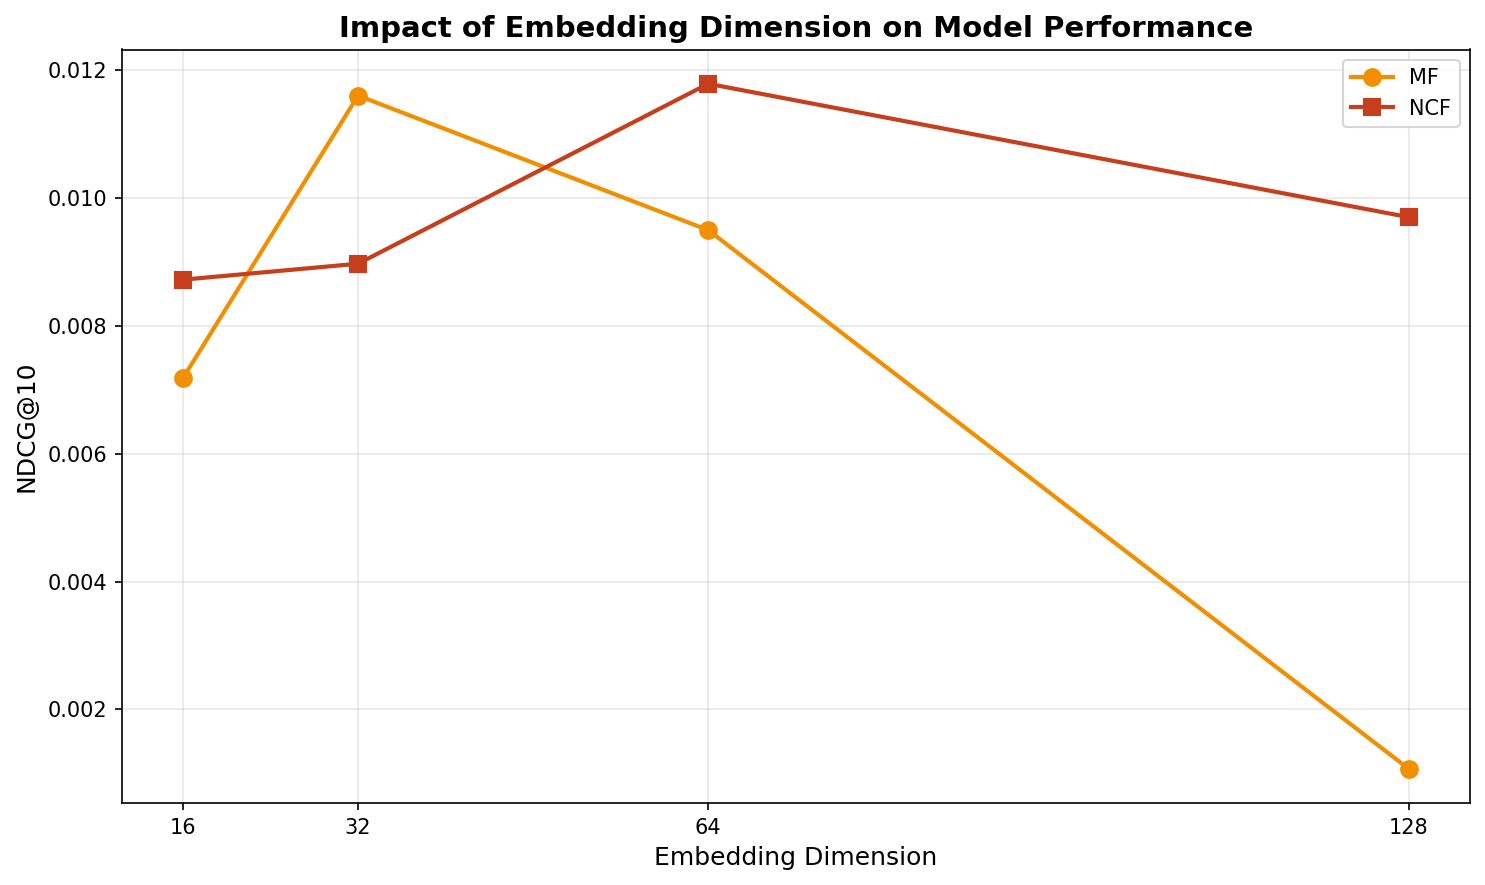


ABLATION STUDY COMPLETE


In [6]:
# Create visualization
fig, ax = plt.subplots(figsize=(10, 6))

mf_data = results_df[results_df['Model'] == 'MF']
ncf_data = results_df[results_df['Model'] == 'NCF']

ax.plot(mf_data['Embedding Dim'], mf_data['NDCG@10'], 'o-', linewidth=2, markersize=8, label='MF', color='#F18F01')
ax.plot(ncf_data['Embedding Dim'], ncf_data['NDCG@10'], 's-', linewidth=2, markersize=8, label='NCF', color='#C73E1D')

ax.set_xlabel('Embedding Dimension', fontsize=12)
ax.set_ylabel('NDCG@10', fontsize=12)
ax.set_title('Impact of Embedding Dimension on Model Performance', fontsize=14, fontweight='bold')
ax.set_xticks(embedding_dims)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig_ablation.png', bbox_inches='tight')
print(f"Saved: {FIGURES_DIR}/fig_ablation.png")
plt.show()

print("\n" + "=" * 50)
print("ABLATION STUDY COMPLETE")
print("=" * 50)
